# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "hfc152a"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[0.8300000000000001 0.8586666666666668 0.8873333333333334 ... 2.452 2.452 2.452] [0.8300000000000001 0.8586666666666668 0.9700000000000001 ... 2.452 2.452 2.452] [0.8300000000000001 0.9 1.0939999999999999 ... 2.452 2.452 2.452] [0.8300000000000001 0.9824444444444446 1.1348888888888888 ... 2.452 2.452 2.452] [0.8300000000000001 0.8586666666666667 0.9492222222222223 ... 2.452 2.452 2.452] [0.8300000000000001 0.8586666666666668 0.8873333333333334 ... 2.452 2.452 2.452]] [[0.895 0.8996666666666667 0.9043333333333334 ... 2.444 2.444 2.444] [0.895 0.8996666666666667 0.9956666666666667 ... 2.444 2.444 2.444] [0.895 0.9453333333333334 1.1326666666666665 ... 2.444 2.444 2.444] [0.895 1.0380000000000003 1.1809999999999998 ... 2.444 2.444 2.444] [0.895 0.8996666666666667 0.9735 ... 2.444 2.444 2.444] [0.895 0.8996666666666667 0.9043333333333333 ... 2.444 2.444 2.444]] [[0.915 0.9670000000000001 0.965 ... 2.595 2.595 2.595] [0.915 0.985 1.1616666666666666 ... 2.595 2.595 2.595] [0.915 1.0467647058823528 1.240294117647059 ... 2.595 2.595 2.595] [0.915 1.0764285714285713 1.2378571428571428 ... 2.595 2.595 2.595] [0.915 0.931 1.0107142857142857 ... 2.595 2.595 2.595] [0.915 0.9490000000000001 0.947 ... 2.595 2.595 2.595]] ... [[5.38 5.38 5.38 ... 11.942083333333333 11.446666666666667 11.495] [5.38 5.38 5.38 ... 15.38 13.4375 11.495] [5.38 5.38 5.38 ... 11.21 11.362962962962962 11.495] [5.38 5.38 5.38 ... 11.046666666666667 11.383888888888889 11.495] [5.38 5.38 5.38 ... 10.883333333333335 11.404814814814817 11.495] [5.38 5.38 5.38 ... 10.72 11.425740740740743 11.495]] [[5.1975 5.1975 5.1975 ... 14.04625 11.6525 11.845] [5.1975 5.1975 5.1975 ... 13.42 12.6325 11.845] [5.1975 5.1975 5.1975 ... 17.17 14.190277777777778 11.845] [5.1975 5.1975 5.1975 ... 15.500462962962965 13.555833333333334 11.845] [5.1975 5.1975 5.1975 ... 13.830925925925927 12.92138888888889 11.845] [5.1975 5.1975 5.1975 ... 12.16138888888889 12.286944444444446 11.845]] [[5.13 5.13 5.13 ... 14.439999999999998 11.873333333333331 11.873333333333331] [5.13 5.13 5.13 ... 14.28 11.873333333333331 11.873333333333331] [5.13 5.13 5.13 ... 12.17 11.873333333333331 11.873333333333331] [5.13 5.13 5.13 ... 11.843333333333334 11.873333333333331 11.873333333333331] [5.13 5.13 5.13 ... 11.516666666666666 11.873333333333331 11.873333333333331] [5.13 5.13 5.13 ... 11.189999999999998 11.873333333333331 11.873333333333331]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[0.8300000000000001 0.8586666666666668 0.8873333333333334 ... 2.452 2.452 2.452] [0.8300000000000001 0.8586666666666668 0.9700000000000001 ... 2.452 2.452 2.452] [0.8300000000000001 0.9 1.0939999999999999 ... 2.452 2.452 2.452] [0.8300000000000001 0.9824444444444446 1.1348888888888888 ... 2.452 2.452 2.452] [0.8300000000000001 0.8586666666666667 0.9492222222222223 ... 2.452 2.452 2.452] [0.8300000000000001 0.8586666666666668 0.8873333333333334 ... 2.452 2.452 2.452]] [[0.895 0.8996666666666667 0.9043333333333334 ... 2.444 2.444 2.444] [0.895 0.8996666666666667 0.9956666666666667 ... 2.444 2.444 2.444] [0.895 0.9453333333333334 1.1326666666666665 ... 2.444 2.444 2.444] [0.895 1.0380000000000003 1.1809999999999998 ... 2.444 2.444 2.444] [0.895 0.8996666666666667 0.9735 ... 2.444 2.444 2.444] [0.895 0.8996666666666667 0.9043333333333333 ... 2.444 2.444 2.444]] [[0.915 0.9670000000000001 0.965 ... 2.595 2.595 2.595] [0.915 0.985 1.1616666666666666 ... 2.595 2.595 2.595] [0.915 1.0467647058823528 1.240294117647059 ... 2.595 2.595 2.595] [0.915 1.0764285714285713 1.2378571428571428 ... 2.595 2.595 2.595] [0.915 0.931 1.0107142857142857 ... 2.595 2.595 2.595] [0.915 0.9490000000000001 0.947 ... 2.595 2.595 2.595]] ... [[5.38 5.38 5.38 ... 11.942083333333333 11.446666666666667 11.495] [5.38 5.38 5.38 ... 15.38 13.4375 11.495] [5.38 5.38 5.38 ... 11.21 11.362962962962962 11.495] [5.38 5.38 5.38 ... 11.046666666666667 11.383888888888889 11.495] [5.38 5.38 5.38 ... 10.883333333333335 11.404814814814817 11.495] [5.38 5.38 5.38 ... 10.72 11.425740740740743 11.495]] [[5.1975 5.1975 5.1975 ... 14.04625 11.6525 11.845] [5.1975 5.1975 5.1975 ... 13.42 12.6325 11.845] [5.1975 5.1975 5.1975 ... 17.17 14.190277777777778 11.845] [5.1975 5.1975 5.1975 ... 15.500462962962965 13.555833333333334 11.845] [5.1975 5.1975 5.1975 ... 13.830925925925927 12.92138888888889 11.845] [5.1975 5.1975 5.1975 ... 12.16138888888889 12.286944444444446 11.845]] [[5.13 5.13 5.13 ... 14.439999999999998 11.873333333333331 11.873333333333331] [5.13 5.13 5.13 ... 14.28 11.873333333333331 11.873333333333331] [5.13 5.13 5.13 ... 12.17 11.873333333333331 11.873333333333331] [5.13 5.13 5.13 ... 11.843333333333334 11.873333333333331 11.873333333333331] [5.13 5.13 5.13 ... 11.516666666666666 11.873333333333331 11.873333333333331] [5.13 5.13 5.13 ... 11.189999999999998 11.873333333333331 11.873333333333331]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'hfc152a' (lon: 6, lat: 12, year: 24, month: 12)> Size: 166kB
<Quantity([[[[ 1.13333333  1.075       0.97       ...  1.4         1.135
     1.15      ]
   [ 1.00666667  1.16333333  1.08333333 ...  1.44333333  1.44
     1.47      ]
   [ 1.37333333  1.41333333  1.39       ...  1.67666667  1.745
     1.77      ]
   ...
   [ 4.7275      4.5725      4.6        ...  5.28        5.115
     4.99      ]
   [ 4.78        4.70666667  4.65       ...  5.265       5.14666667
     5.        ]
   [ 4.79        4.645       4.86       ...  5.465       5.38
     5.1975    ]]

  [[ 0.94470833  1.09516667  1.15105    ...  1.16175     1.087825
     1.20375   ]
   [ 1.15098333  1.16451667  0.98425    ...  1.51695     1.454325
     1.59085   ]
   [ 1.46131667  1.342925    1.31655    ...  1.86513333  1.74928333
     1.755     ]
...
   [11.42008333 11.62925    11.33241667 ...  9.79169444 10.5465
    10.96175   ]
   [10.92933333 11.16772222 11.35177778 ... 10.0935     10.73958333
    11.43683333]
   [11.676875   11.7325     11.963      ... 11.01144444 11.42574074
    12.28694444]]

  [[ 2.92        2.87525     3.0315     ...  2.8195      2.90775
     3.2985    ]
   [ 3.34575     3.468       3.465      ...  3.386       3.60133333
     3.93966667]
   [ 4.03783333  4.32        4.3545     ...  4.087       4.55866667
     4.80225   ]
   ...
   [11.5765     11.5205     11.473      ...  9.901      10.68333333
    11.0095    ]
   [11.046      11.22375    11.38333333 ... 10.02716667 10.6665
    11.46966667]
   [11.664      11.6725     11.9825     ... 10.826      11.495
    11.845     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 192B 2001 2002 2003 2004 2005 ... 2021 2022 2023 2024
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[1.1333333333333335 1.075 0.97 ... 5.465 5.38 5.1975] [0.9447083333333334 1.0951666666666666 1.15105 ... 5.4575000000000005 5.38 5.1975] [0.9602083333333333 1.0858333333333334 1.1252499999999999 ... 5.45 5.38 5.1975] ... [2.5991666666666666 2.5861111111111112 2.8288888888888892 ... 13.874666666666666 11.942083333333333 14.04625] [2.92 2.835 2.966 ... 10.846 11.446666666666667 11.6525] [2.92 2.8263749999999996 3.02575 ... 10.826 11.495 11.845]] [[1.1333333333333335 1.075 0.97 ... 5.465 5.38 5.1975] [0.8766666666666666 1.1049999999999998 1.2199999999999998 ... 5.4575 5.38 5.1975] [1.8744642857142857 1.3448809523809524 1.4798214285714286 ... 5.849649122807018 5.38 5.1975] ... [8.85 2.92 3.065 ... 10.64 15.38 13.42] [2.92 2.84875 3.0425 ... 10.733 13.4375 12.6325] [2.92 2.7775 3.02 ... 10.826 11.495 11.845]] [[1.1333333333333335 1.075 0.97 ... 5.465 5.38 5.1975] [1.1104117647058824 1.1968235294117648 1.2040588235294116 ... 5.657324561403509 5.38 5.1975] [1.3212352941176473 1.4104705882352941 1.4221764705882354 ... 6.449122807017544 5.38 5.1975] ... [2.797 2.906 2.949 ... 12.355 11.21 17.17] [2.92 2.890625 2.99025 ... 11.507777777777777 11.362962962962962 14.190277777777778] [2.92 2.87525 3.0315000000000003 ... 10.826 11.495 11.845]] [[1.1333333333333335 1.075 0.97 ... 5.465 5.38 5.1975] [1.299851851851852 1.2467777777777778 1.170111111111111 ... 6.120119047619046 5.38 5.1975] [1.4663703703703705 1.4185555555555556 1.370222222222222 ... 6.7752380952380955 5.38 5.1975] ... [2.632 2.621 2.771 ... 11.76364814814815 11.046666666666667 15.500462962962965] [2.92 2.7969999999999997 2.907 ... 11.342333333333334 11.383888888888889 13.555833333333334] [2.92 2.973 3.043 ... 10.826 11.495 11.845]] [[1.1333333333333335 1.075 0.97 ... 5.465 5.38 5.1975] [1.0807916666666668 1.0755000000000001 1.01315 ... 5.4575 5.38 5.1975] [1.171800925925926 1.1567222222222224 1.1003055555555556 ... 5.781309523809523 5.38 5.1975] ... [2.6389875000000003 2.607483333333333 2.7424749999999998 ... 11.172296296296297 10.883333333333335 13.830925925925927] [2.92 2.8096666666666668 2.9266666666666667 ... 11.176888888888888 11.404814814814817 12.92138888888889] [2.92 2.924125 3.0372500000000002 ... 10.826 11.495 11.845]] [[1.1333333333333335 1.075 0.97 ... 5.465 5.38 5.1975] [1.0127500000000003 1.0853333333333335 1.0821 ... 5.4575 5.38 5.1975] [1.02825 1.076 1.0563 ... 5.449999999999999 5.38 5.1975] ... [2.645975 2.5939666666666668 2.71395 ... 10.580944444444444 10.72 12.16138888888889] [2.92 2.8223333333333334 2.9463333333333335 ... 11.011444444444445 11.425740740740743 12.286944444444446] [2.92 2.87525 3.0315000000000003 ... 10.826 11.495 11.845]]]
Units,ppt


### Longitudinal-mean

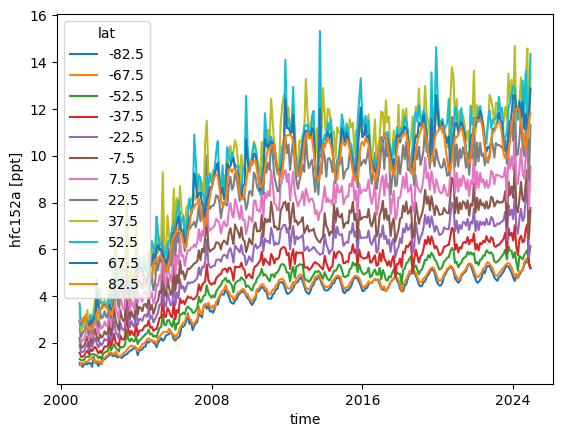

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

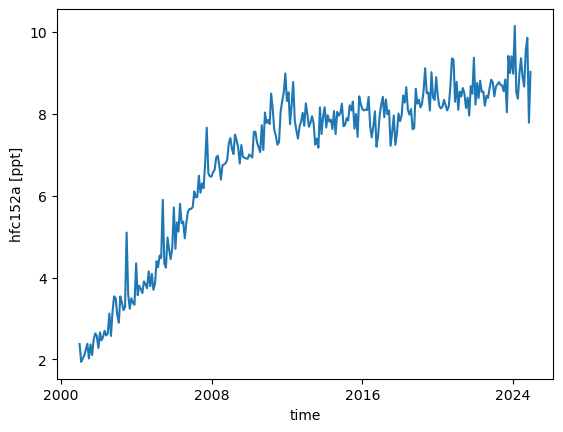

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

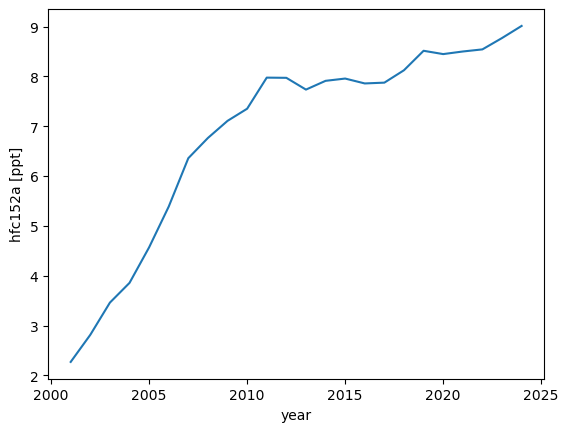

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 4kB
Dimensions:               (lat: 12, eof: 12, year: 24)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 192B 2001 2002 2003 ... 2022 2023 2024
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.4191 ... 0.05329
    principal-components  (year, eof) float64 2kB [] -2.541 ... -5.078e-16

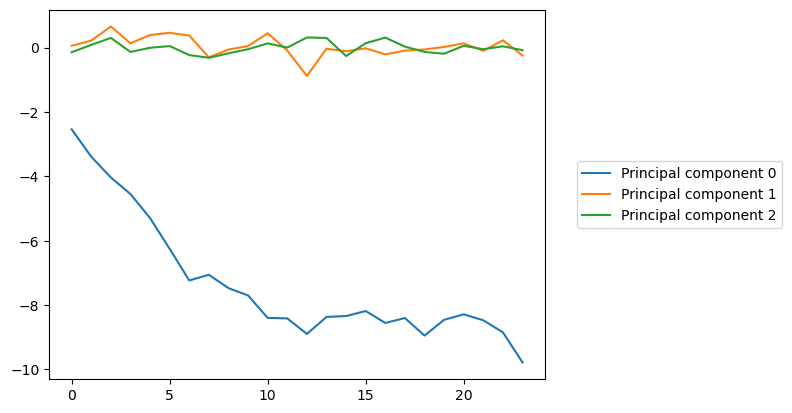

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

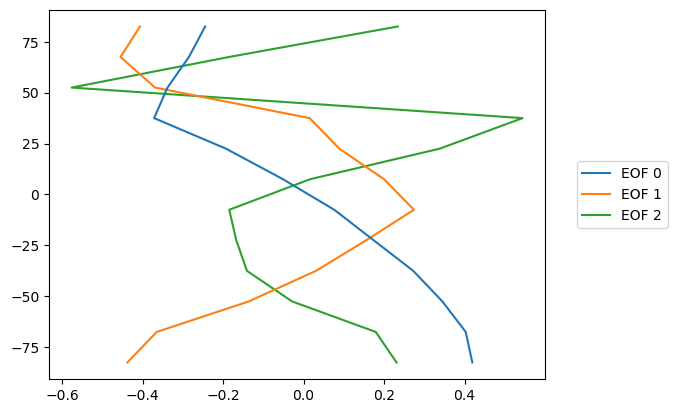

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

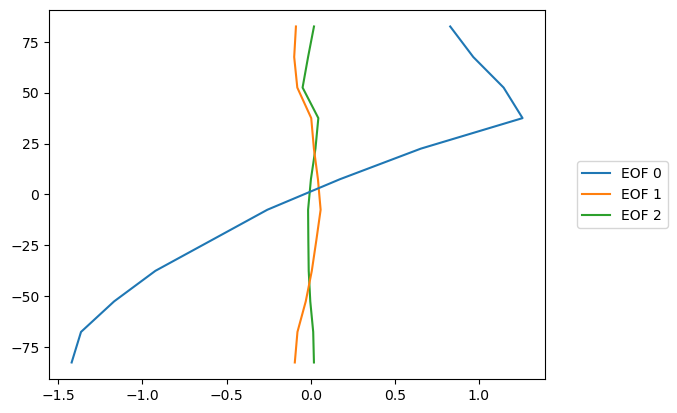

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.4190750651433492] [0.4026554611799382] [0.3446107900996757] [0.27227480366226126] [0.17406821518245816] [0.07598289937517806] [-0.05133406096531954] [-0.19297716643717316] [-0.37141538149974274] [-0.33819665181099295] [-0.2850481792166949] [-0.24459591471144393]]
Units,ppt
Magnitude,[[-2.540869039776833] [-3.3896714415836744] [-4.036179246958983] [-4.551246495098238] [-5.298299955345269] [-6.252943658673545] [-7.236272488655742] [-7.059102954661988] [-7.474477292432431] [-7.7010441560817116] [-8.399208714112678] [-8.4145358919996] [-8.897112553051235] [-8.369270309116333] [-8.341303806970878] [-8.185589183407972] [-8.556925516518383] [-8.403255736927708] [-8.94829497923349] [-8.458500531307976] [-8.289205301329426] [-8.473511658235642] [-8.8495653017026] [-9.784153927982361]]
Units,dimensionless


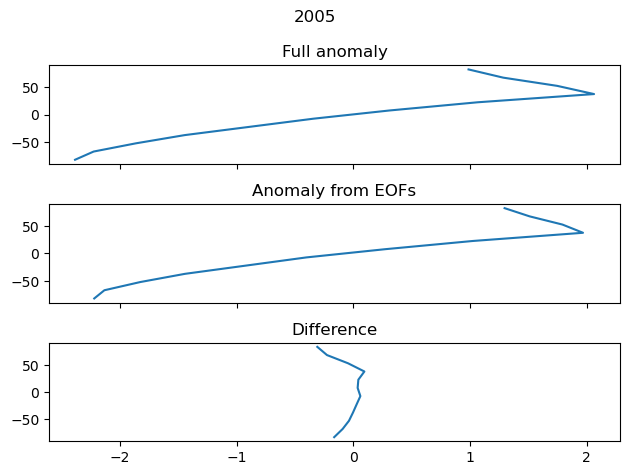

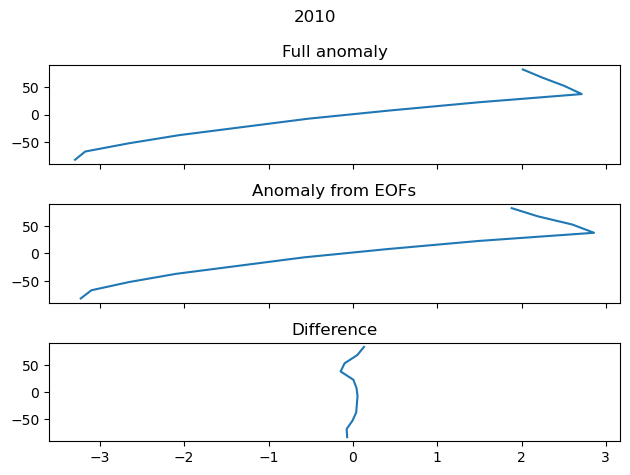

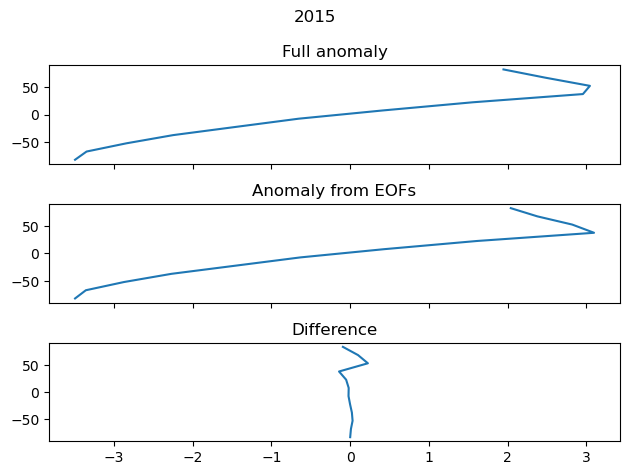

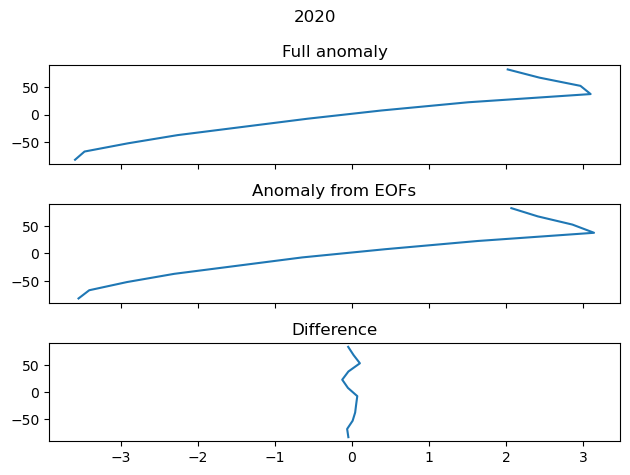

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/288 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 288/288 [00:00<00:00, 11286.60it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/288 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/288 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 288/288 [00:00<00:00, 19418.70it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/288 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 288/288 [00:00<00:00, 17916.13it/s]

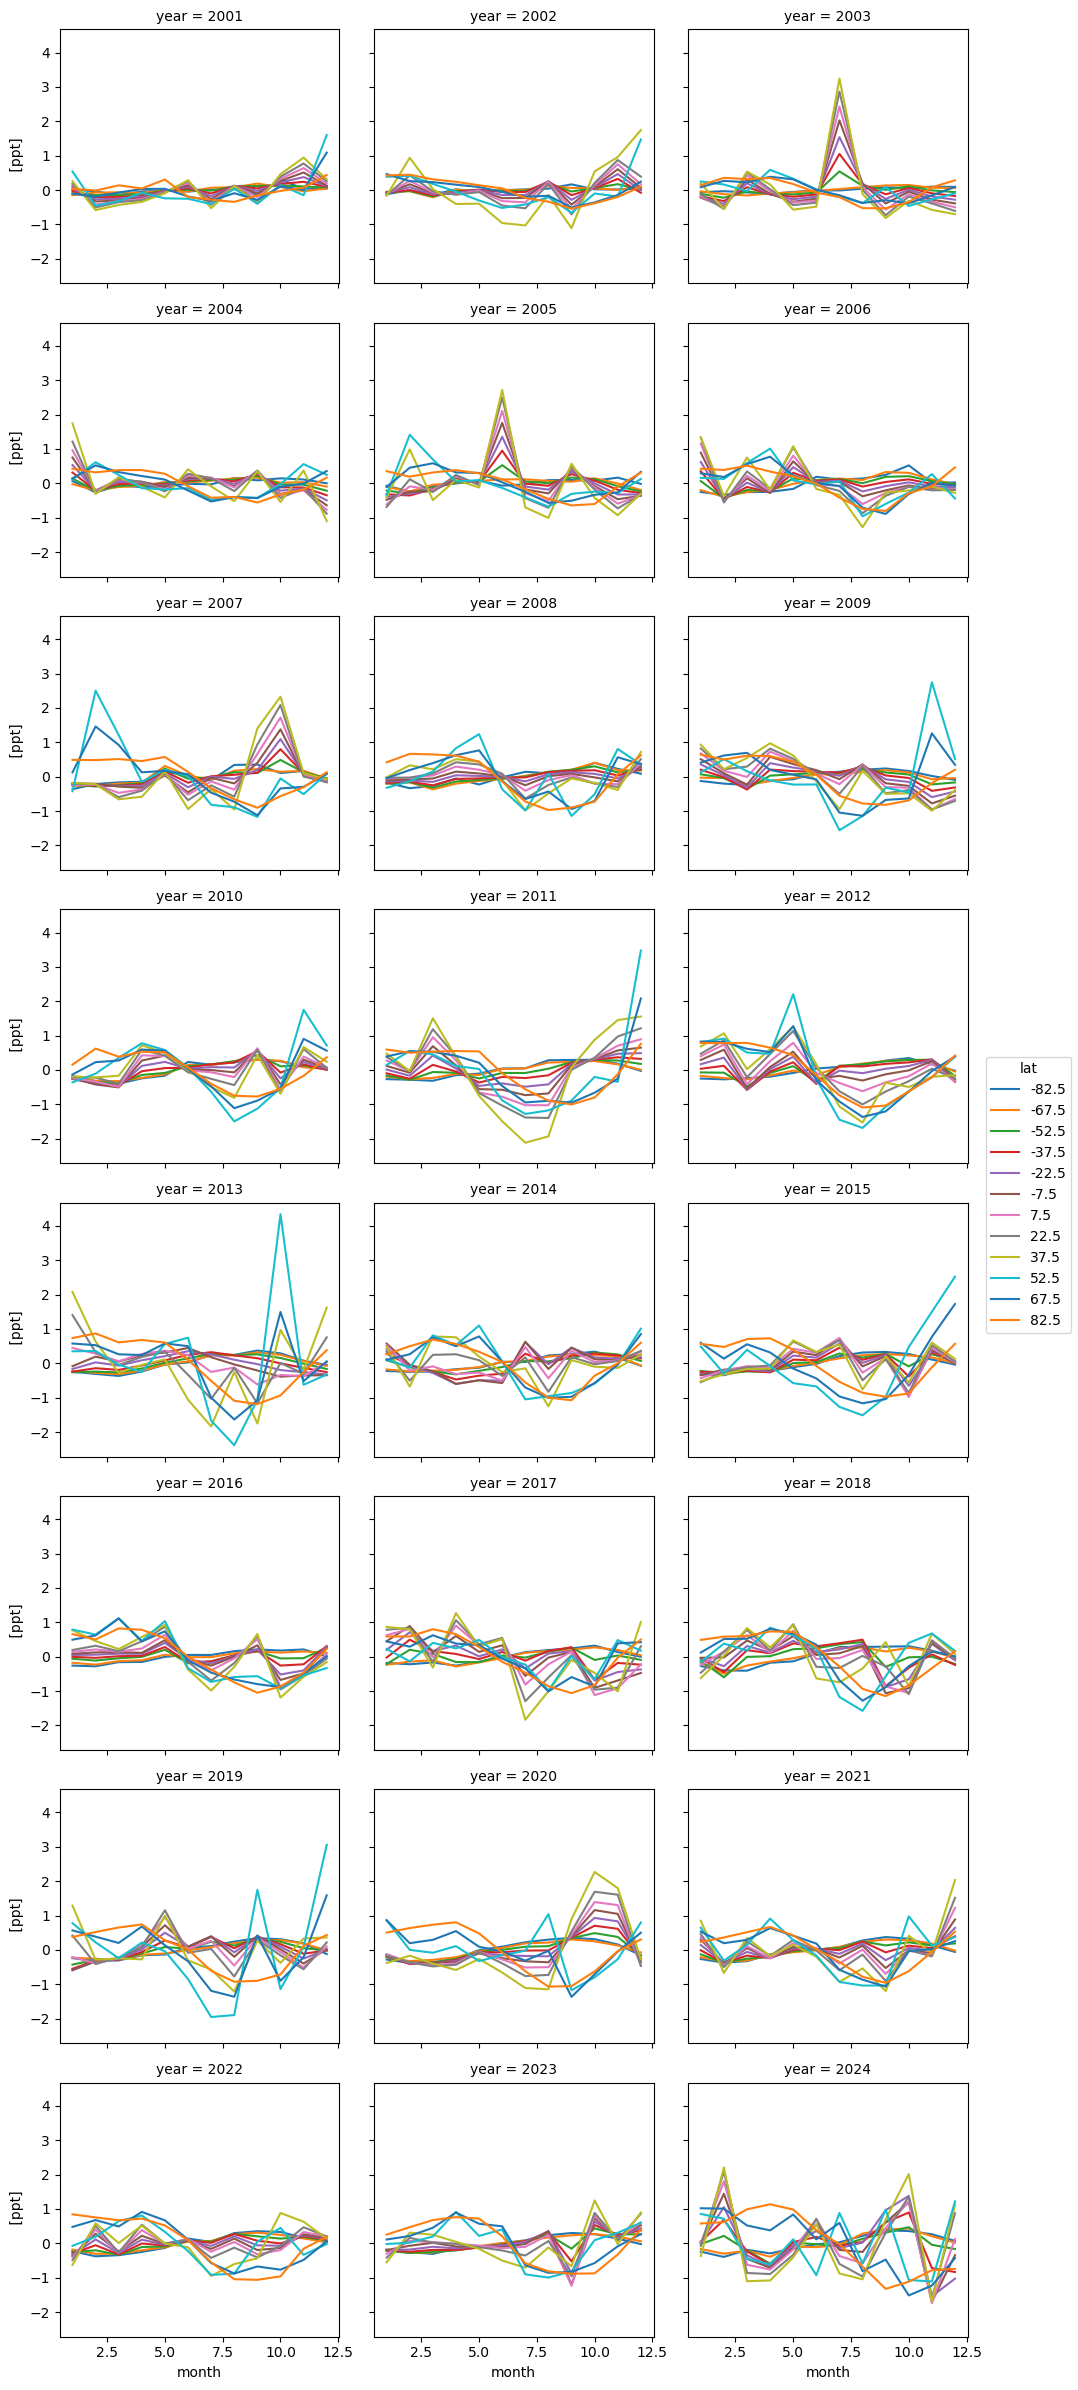

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

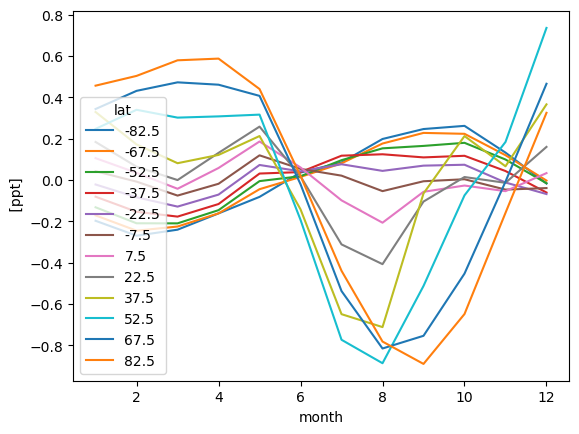

In [22]:
seasonality.plot.line(hue="lat")

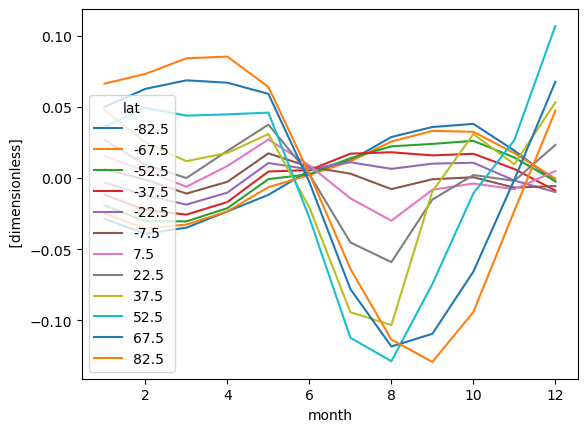

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[2.2695690697985795 2.8138129464675017 3.4602095684659613 3.856139512491066 4.569923718863691 5.387822090218195 6.359595390334131 6.765942174931556 7.108873952559763 7.352579197944753 7.976764735954379 7.972769212188974 7.736546617924433 7.912338704527941 7.958110194615197 7.859972232604115 7.87606312699397 8.12506082101225 8.515713522036707 8.44920243063843 8.501345170146662 8.543702417588724 8.771326669393435 9.014737268570222]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.4190750651433492] [0.4026554611799382] [0.3446107900996757] [0.27227480366226126] [0.17406821518245816] [0.07598289937517806] [-0.05133406096531954] [-0.19297716643717316] [-0.37141538149974274] [-0.33819665181099295] [-0.2850481792166949] [-0.24459591471144393]]
Units,ppt
Magnitude,[[-2.540869039776833] [-3.3896714415836744] [-4.036179246958983] [-4.551246495098238] [-5.298299955345269] [-6.252943658673545] [-7.236272488655742] [-7.059102954661988] [-7.474477292432431] [-7.7010441560817116] [-8.399208714112678] [-8.4145358919996] [-8.897112553051235] [-8.369270309116333] [-8.341303806970878] [-8.185589183407972] [-8.556925516518383] [-8.403255736927708] [-8.94829497923349] [-8.458500531307976] [-8.289205301329426] [-8.473511658235642] [-8.8495653017026] [-9.784153927982361]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.028596275998536896 -0.039085024486596516 -0.034846704937393225 -0.023385999488564582 -0.011778774465826784 0.005336745848225608 0.012407443562944903 0.02891646060649005 0.03591233318765091 0.03814315725750005 0.019348708267080877 -0.0023720756817713633] [-0.02480152781707861 -0.03554464191252668 -0.03263156105231082 -0.023380470452678048 -0.00638452259280635 0.0022324600078819008 0.01182933539240919 0.025722105373247192 0.03319554426725346 0.032553403273356755 0.017523671833592866 -0.0003137987424807031] [-0.01910896325833178 -0.030345872387862006 -0.030405677633425287 -0.02112053819673336 -0.0006983481011273284 0.0027586278491970153 0.014019266454454839 0.022339528606097767 0.024049953177600884 0.02622222619278276 0.01448555551135753 -0.002195717131785657] [-0.011656286544313247 -0.02226445155223364 -0.025654761558525332 -0.0168081575194329 0.004623702421435095 0.005659736328611684 0.01717397477399413 0.018173200660632948 0.015972995747497457 0.017102334336143606 0.0063886264704445615 -0.008710868138977462] [-0.003073778470987755 -0.012059079935208763 -0.018622539419411454 -0.010183038581978153 0.010645390916170195 0.006146919925350316 0.01114635816431623 0.006497723483890128 0.010176280531723522 0.010806370646750453 -0.0016898647054761297 -0.009790717014506543] [0.006248758456589007 -0.001066268261028448 -0.010874655724404703 -0.002572797321178312 0.017425579988219867 0.00789193340836053 0.0031389200850834415 -0.007741352002992245 -0.0008051907834973223 0.000615881829391542 -0.006669460648547312 -0.005591320682087157] [0.015437490749009648 0.0051284925911740395 -0.006085039313806959 0.008524928175668018 0.027150460503729035 0.008894819003182383 -0.014227699712274706 -0.029941983545430578 -0.008217521673566461 -0.0038201430543176834 -0.0077628709093458745 0.00491909328915806] [0.026827086373555627 0.009442039127273443 3.306994916104907e-05 0.01915474359880314 0.03761385995802225 0.002661485190714099 -0.04519699215288319 -0.059079494150762975 -0.015076924628357443 0.0021699359306129144 -0.0019028196769682326 0.023354087030862856] [0.04788956128728654 0.02509291039829809 0.01188905914656914 0.017716452531014934 0.030984690376915154 -0.020564930995507623 -0.09424596114849104 -0.10333299007869172 -0.009369053409273707 0.030963929540017726 0.009725681140998919 0.05325070147989079] [0.0360100839162005 0.04944747682166446 0.043935899344979976 0.04481052848994153 0.04604493113863725 -0.027938564833328378 -0.1122480077982011 -0.12873273587910963 -0.07441876887757501 -0.010722692225578787 0.026810044547188747 0.10700169373173944] [0.049993175777019894 0.06275866098854647 0.06874473477149425 0.06708216775423764 0.05922171269561718 -0.0028897216080575275 -0.07800248887006557 -0.11838602205463677 -0.10945310115068607 -0.06573821173861365 -0.0010694686629258879 0.06773834215503136] [0.06640300990863125 0.07327468938046927 0.08423599693813572 0.08542810569176511 0.06404203377350708 0.0029624790387333014 -0.06375505814102651 -0.11350407661205833 -0.1292256233606598 -0.09414895203527432 -0.0230177081483751 0.04730489894110371]]
Units,dimensionless
